In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_excel("flight_price.xlsx")
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


Description: The various features of the data are explained below:

Airline: The name of the airline company is stored in the airline column. It is a categorical feature having 6 different airlines.

Flight: Flight stores information regarding the plane's flight code. It is a categorical feature.

Source City: City from which the flight takes off. It is a categorical feature having 6 unique cities.

Departure Time: This is a derived categorical feature obtained created by grouping time periods into bins. It stores information about the departure time and have 6 unique time labels.

Stops: A categorical feature with 3 distinct values that stores the number of stops between the source and destination cities.

Arrival Time: This is a derived categorical feature created by grouping time intervals into bins. It has six distinct time labels and keeps information about the arrival time.

Destination City: City where the flight will land. It is a categorical feature having 6 unique cities.

Class: A categorical feature that contains information on seat class; it has two distinct values: Business and Economy.

Duration: A continuous feature that displays the overall amount of time it takes to travel between cities in hours.

10)Days Left: This is a derived characteristic that is calculated by subtracting the trip date by the booking date.

Price: Target variable stores information of the ticket price.


In [4]:
df.sample(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
1538,Air India,18/03/2019,Banglore,New Delhi,BLR → BOM → IDR → DEL,06:45,11:10 16 Mar,28h 25m,2 stops,No info,11234
348,Air India,9/06/2019,Kolkata,Banglore,CCU → BOM → COK → BLR,09:25,13:45 10 Jun,28h 20m,2 stops,No info,11542
6194,IndiGo,3/03/2019,Delhi,Cochin,DEL → MAA → COK,09:55,15:10,5h 15m,1 stop,No info,12214
8454,Jet Airways,27/05/2019,Delhi,Cochin,DEL → COK,11:00,14:15,3h 15m,non-stop,In-flight meal not included,7989
59,Vistara,6/03/2019,Mumbai,Hyderabad,BOM → DEL → HYD,15:40,16:45 07 Mar,25h 5m,1 stop,No info,12395


In [5]:
df.shape

(10683, 11)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


In [7]:
df.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [9]:
#routes has null values, as per understanding, a flight can't go from one place to another without any route
#so we need to drop the null values


In [10]:
df.dropna(axis=0,inplace=True)

In [11]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [12]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='str')

In [13]:
df['Date_of_Journey']

0        24/03/2019
1         1/05/2019
2         9/06/2019
3        12/05/2019
4        01/03/2019
            ...    
10678     9/04/2019
10679    27/04/2019
10680    27/04/2019
10681    01/03/2019
10682     9/05/2019
Name: Date_of_Journey, Length: 10682, dtype: str

In [14]:
df["day"] = df["Date_of_Journey"].str.split('/').str[0]
df["month"] = df["Date_of_Journey"].str.split('/').str[1]
df["year"] = df["Date_of_Journey"].str.split('/').str[2]

In [15]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,day,month,year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,03,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,05,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,06,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,05,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,01,03,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,04,2019
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,04,2019
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,04,2019
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,01,03,2019


In [16]:
df.dtypes

Airline               str
Date_of_Journey       str
Source                str
Destination           str
Route                 str
Dep_Time              str
Arrival_Time          str
Duration              str
Total_Stops           str
Additional_Info       str
Price               int64
day                object
month              object
year               object
dtype: object

In [17]:
df['day']=df['day'].astype(int)
df['month']=df['month'].astype(int)
df['year']=df['year'].astype(int)

In [18]:
df.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
day                int64
month              int64
year               int64
dtype: object

In [19]:
df.drop('Date_of_Journey',axis=1,inplace=True)

In [20]:
df.dtypes

Airline              str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
day                int64
month              int64
year               int64
dtype: object

In [21]:
df.Arrival_Time.unique(
)

<StringArray>
['01:10 22 Mar',        '13:15', '04:25 10 Jun',        '23:30',
        '21:35',        '11:25', '10:25 13 Mar', '05:05 02 Mar',
        '19:15',        '23:00',
 ...
 '00:50 25 Jun', '00:50 19 Jun', '05:35 10 May', '02:10 22 Mar',
 '03:35 28 Apr', '00:50 28 Jun', '22:40 07 Jun', '06:50 10 Mar',
 '00:05 19 Mar', '21:20 13 Mar']
Length: 1343, dtype: str

In [22]:
df.Arrival_Time

0        01:10 22 Mar
1               13:15
2        04:25 10 Jun
3               23:30
4               21:35
             ...     
10678           22:25
10679           23:20
10680           11:20
10681           14:10
10682           19:15
Name: Arrival_Time, Length: 10682, dtype: str

In [23]:
df.Arrival_Time=df.Arrival_Time.apply(lambda x:x.split(' ')[0]) #type:ignore

In [24]:
df['Arrival_hour']=df.Arrival_Time.str.split(':').str[0]
df['Arrival_mins']=df.Arrival_Time.str.split(':').str[1]


In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  str   
 1   Source           10682 non-null  str   
 2   Destination      10682 non-null  str   
 3   Route            10682 non-null  str   
 4   Dep_Time         10682 non-null  str   
 5   Arrival_Time     10682 non-null  str   
 6   Duration         10682 non-null  str   
 7   Total_Stops      10682 non-null  str   
 8   Additional_Info  10682 non-null  str   
 9   Price            10682 non-null  int64 
 10  day              10682 non-null  int64 
 11  month            10682 non-null  int64 
 12  year             10682 non-null  int64 
 13  Arrival_hour     10682 non-null  object
 14  Arrival_mins     10682 non-null  object
dtypes: int64(4), object(2), str(9)
memory usage: 1.3+ MB


In [26]:
df['Arrival_hour']=df['Arrival_hour'].astype(int)
df['Arrival_mins']=df['Arrival_mins'].astype(int)

In [27]:
df.dtypes

Airline              str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
day                int64
month              int64
year               int64
Arrival_hour       int64
Arrival_mins       int64
dtype: object

In [28]:
df.drop('Arrival_Time',axis=1,inplace=True)

In [29]:
df.dtypes

Airline              str
Source               str
Destination          str
Route                str
Dep_Time             str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
day                int64
month              int64
year               int64
Arrival_hour       int64
Arrival_mins       int64
dtype: object

In [30]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Dep_Time', 'Duration',
       'Total_Stops', 'Additional_Info', 'Price', 'day', 'month', 'year',
       'Arrival_hour', 'Arrival_mins'],
      dtype='str')

In [31]:
df.Dep_Time

0        22:20
1        05:50
2        09:25
3        18:05
4        16:50
         ...  
10678    19:55
10679    20:45
10680    08:20
10681    11:30
10682    10:55
Name: Dep_Time, Length: 10682, dtype: str

In [32]:
df['Dep_hour']=df.Dep_Time.str.split(':').str[0]
df['Dep_mins']=df.Dep_Time.str.split(':').str[1]

In [33]:
df['Dep_hour']=df['Dep_hour'].astype(int)
df['Dep_mins']=df['Dep_mins'].astype(int)

In [34]:
df.drop('Dep_Time',axis=1,inplace=True)

In [35]:
df.dtypes

Airline              str
Source               str
Destination          str
Route                str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
day                int64
month              int64
year               int64
Arrival_hour       int64
Arrival_mins       int64
Dep_hour           int64
Dep_mins           int64
dtype: object

In [36]:
df.Total_Stops

0        non-stop
1         2 stops
2         2 stops
3          1 stop
4          1 stop
           ...   
10678    non-stop
10679    non-stop
10680    non-stop
10681    non-stop
10682     2 stops
Name: Total_Stops, Length: 10682, dtype: str

In [37]:
df.Total_Stops.unique()

<StringArray>
['non-stop', '2 stops', '1 stop', '3 stops', '4 stops']
Length: 5, dtype: str

In [38]:
df.Total_Stops.isna().sum()

np.int64(0)

In [39]:
df.Total_Stops=df.Total_Stops.map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4}) #type:ignore

In [40]:
df.Total_Stops

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: Total_Stops, Length: 10682, dtype: int64

In [41]:
df.dtypes

Airline              str
Source               str
Destination          str
Route                str
Duration             str
Total_Stops        int64
Additional_Info      str
Price              int64
day                int64
month              int64
year               int64
Arrival_hour       int64
Arrival_mins       int64
Dep_hour           int64
Dep_mins           int64
dtype: object

In [42]:
#Route can be used in two ways
#To know source and destination>> which is already in the data
#as number of stops>> total stops is already there
#So route is a repeatative information

In [43]:
df.drop('Route',axis=1,inplace=True)

In [44]:
df.Duration

0        2h 50m
1        7h 25m
2           19h
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680        3h
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: str

In [45]:
df['Duration_hours']=df.Duration.str.split(' ').str[0].str.split('h').str[0]

In [46]:
df['Duration_mins']=df.Duration.str.split(' ').str[1].str.split('m').str[0]

In [47]:
df.Duration_hours,df.Duration_mins

(0         2
 1         7
 2        19
 3         5
 4         4
          ..
 10678     2
 10679     2
 10680     3
 10681     2
 10682     8
 Name: Duration_hours, Length: 10682, dtype: object,
 0         50
 1         25
 2        NaN
 3         25
 4         45
         ... 
 10678     30
 10679     35
 10680    NaN
 10681     40
 10682     20
 Name: Duration_mins, Length: 10682, dtype: object)

In [48]:
df.Duration_hours.isnull().sum()

np.int64(0)

In [49]:
df.Duration_mins.isnull().sum()

np.int64(1032)

In [50]:
df['Duration_mins'] = pd.to_numeric(df['Duration_mins'], errors='coerce').fillna(0).astype(int)
df.Duration_mins.isnull().sum()

np.int64(0)

In [51]:
df['Duration_hours'] = pd.to_numeric(df['Duration_hours'], errors='coerce').fillna(0).astype(int)

In [52]:
df.Duration_mins

0        50
1        25
2         0
3        25
4        45
         ..
10678    30
10679    35
10680     0
10681    40
10682    20
Name: Duration_mins, Length: 10682, dtype: int64

In [53]:
df.info()

<class 'pandas.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10682 non-null  str  
 1   Source           10682 non-null  str  
 2   Destination      10682 non-null  str  
 3   Duration         10682 non-null  str  
 4   Total_Stops      10682 non-null  int64
 5   Additional_Info  10682 non-null  str  
 6   Price            10682 non-null  int64
 7   day              10682 non-null  int64
 8   month            10682 non-null  int64
 9   year             10682 non-null  int64
 10  Arrival_hour     10682 non-null  int64
 11  Arrival_mins     10682 non-null  int64
 12  Dep_hour         10682 non-null  int64
 13  Dep_mins         10682 non-null  int64
 14  Duration_hours   10682 non-null  int64
 15  Duration_mins    10682 non-null  int64
dtypes: int64(11), str(5)
memory usage: 1.4 MB


In [54]:
df.drop('Duration',axis=1,inplace=True)

In [55]:
df.dtypes

Airline              str
Source               str
Destination          str
Total_Stops        int64
Additional_Info      str
Price              int64
day                int64
month              int64
year               int64
Arrival_hour       int64
Arrival_mins       int64
Dep_hour           int64
Dep_mins           int64
Duration_hours     int64
Duration_mins      int64
dtype: object

In [56]:
df.Additional_Info.unique()

<StringArray>
[                     'No info',  'In-flight meal not included',
 'No check-in baggage included',              '1 Short layover',
                      'No Info',               '1 Long layover',
              'Change airports',               'Business class',
               'Red-eye flight',               '2 Long layover']
Length: 10, dtype: str

In [57]:
df.Additional_Info.value_counts()

Additional_Info
No info                         8344
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [58]:
#either we drop additional info or drop it

In [59]:
df[["Airline", "Source", "Destination", "Additional_Info"]]

,Airline,Source,Destination,Additional_Info
0,IndiGo,Banglore,New Delhi,No info
1,Air India,Kolkata,Banglore,No info
2,Jet Airways,Delhi,Cochin,No info
3,IndiGo,Kolkata,Banglore,No info
4,IndiGo,Banglore,New Delhi,No info
...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,No info
10679,Air India,Kolkata,Banglore,No info
10680,Jet Airways,Banglore,Delhi,No info
10681,Vistara,Banglore,New Delhi,No info


In [60]:
#all of the above categorical data is nominal data, so we will be using one hot encoding
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

In [61]:
encoder

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_catego

In [62]:
encoder.fit_transform(df[["Airline", "Source", "Destination", "Additional_Info"]]).toarray() #type:ignore

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.]], shape=(10682, 33))

In [63]:
encoder.get_feature_names_out()

array(['Airline_Air Asia', 'Airline_Air India', 'Airline_GoAir',
       'Airline_IndiGo', 'Airline_Jet Airways',
       'Airline_Jet Airways Business', 'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara',
       'Airline_Vistara Premium economy', 'Source_Banglore',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai', 'Destination_Banglore', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi',
       'Additional_Info_1 Long layover',
       'Additional_Info_1 Short layover',
       'Additional_Info_2 Long layover', 'Additional_Info_Business class',
       'Additional_Info_Change airports',
       'Additional_Info_In-flight meal not included',
       'Additional_Info_No Info',
       'Additional_Info_No check-in baggage included',
       'Additional_Info_No info', 'Additional_Info_Red-eye fli

In [64]:
encoded_data=encoder.fit_transform(df[["Airline", "Source", "Destination", "Additional_Info"]]).toarray() #type:ignore
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out())

In [65]:
df.drop(['Airline', 'Source', 'Destination', 'Additional_Info'], axis=1, inplace = True)

In [66]:
encoded_df

,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,...,Additional_Info_1 Long layover,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10677,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10678,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10679,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [67]:
final_df = pd.concat([df, encoded_df], axis = 1)

In [68]:
final_df

,Total_Stops,Price,day,month,year,Arrival_hour,Arrival_mins,Dep_hour,Dep_mins,Duration_hours,...,Additional_Info_1 Long layover,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,0.0,3897.0,24.0,3.0,2019.0,1.0,10.0,22.0,20.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2.0,7662.0,1.0,5.0,2019.0,13.0,15.0,5.0,50.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2.0,13882.0,9.0,6.0,2019.0,4.0,25.0,9.0,25.0,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,6218.0,12.0,5.0,2019.0,23.0,30.0,18.0,5.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,13302.0,1.0,3.0,2019.0,21.0,35.0,16.0,50.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10679,0.0,4145.0,27.0,4.0,2019.0,23.0,20.0,20.0,45.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10680,0.0,7229.0,27.0,4.0,2019.0,11.0,20.0,8.0,20.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10681,0.0,12648.0,1.0,3.0,2019.0,14.0,10.0,11.0,30.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10682,2.0,11753.0,9.0,5.0,2019.0,19.0,15.0,10.0,55.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
final_df.dtypes

Total_Stops                                     float64
Price                                           float64
day                                             float64
month                                           float64
year                                            float64
Arrival_hour                                    float64
Arrival_mins                                    float64
Dep_hour                                        float64
Dep_mins                                        float64
Duration_hours                                  float64
Duration_mins                                   float64
Airline_Air Asia                                float64
Airline_Air India                               float64
Airline_GoAir                                   float64
Airline_IndiGo                                  float64
Airline_Jet Airways                             float64
Airline_Jet Airways Business                    float64
Airline_Multiple carriers                       

In [70]:
#internal homework
#Univariate analysis
#Bivariate analysis
#multivariate analysis
#considering price as target variable separate X and y
#train test split
#scaling

In [71]:
import seaborn as sns

In [72]:
final_df.isnull().sum()

Total_Stops                                     1
Price                                           1
day                                             1
month                                           1
year                                            1
Arrival_hour                                    1
Arrival_mins                                    1
Dep_hour                                        1
Dep_mins                                        1
Duration_hours                                  1
Duration_mins                                   1
Airline_Air Asia                                1
Airline_Air India                               1
Airline_GoAir                                   1
Airline_IndiGo                                  1
Airline_Jet Airways                             1
Airline_Jet Airways Business                    1
Airline_Multiple carriers                       1
Airline_Multiple carriers Premium economy       1
Airline_SpiceJet                                1


In [73]:
#univariate analysis
final_df.describe()

,Total_Stops,Price,day,month,year,Arrival_hour,Arrival_mins,Dep_hour,Dep_mins,Duration_hours,...,Additional_Info_1 Long layover,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
count,10682.000000,10682.000000,10682.000000,10682.000000,10682.0,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,...,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000
mean,0.824190,9087.214567,13.509081,4.708575,2019.0,13.349186,24.690601,12.491013,24.409287,10.244898,...,0.001779,0.000094,0.000094,0.000374,0.000655,0.185546,0.000281,0.029957,0.781127,0.000094
std,0.675229,4611.548810,8.479363,1.164408,0.0,6.859317,16.506808,5.748820,18.767801,8.494916,...,0.042139,0.009676,0.009676,0.019348,0.025592,0.388758,0.016757,0.170477,0.413502,0.009676
min,0.000000,1759.000000,1.000000,3.000000,2019.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,5277.000000,6.000000,3.000000,2019.0,8.000000,10.000000,8.000000,5.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,1.000000,8372.000000,12.000000,5.000000,2019.0,14.000000,25.000000,11.000000,25.000000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1.000000,12373.000000,21.000000,6.000000,2019.0,19.000000,35.000000,18.000000,40.000000,15.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,4.000000,79512.000000,27.000000,6.000000,2019.0,23.000000,55.000000,23.000000,55.000000,47.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


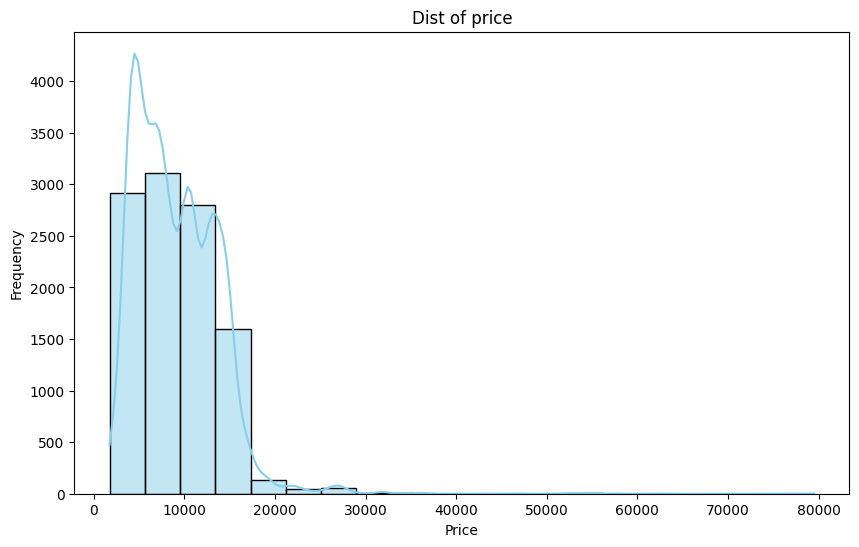

In [74]:
plt.figure(figsize=(10,6))
sns.histplot(final_df['Price'].dropna(),kde=True,bins=20,color='skyblue') #type:ignore
plt.title("Dist of price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [75]:
final_df.Price.skew()

np.float64(1.812404554693161)

In [76]:
final_df.Price.kurt()

np.float64(13.301936765379192)

In [77]:
final_df.Price.mean()

np.float64(9087.21456656057)

In [78]:
final_df.Price.median()

np.float64(8372.0)

In [79]:
#Price is left skewed

In [80]:
y=final_df.Price

In [81]:
cols=['Duration_hours','Duration_mins','day','month','year','Dep_hour','Dep_mins','Arrival_hour','Arrival_mins','Total_Stops']

## Step 1: Univariate Analysis
We will first inspect the target variable and the main numeric features one at a time.

In [82]:
final_df[cols + ['Price']].describe()

,Duration_hours,Duration_mins,day,month,year,Dep_hour,Dep_mins,Arrival_hour,Arrival_mins,Total_Stops,Price
count,10682.000000,10682.000000,10682.000000,10682.000000,10682.0,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000
mean,10.244898,28.326156,13.509081,4.708575,2019.0,12.491013,24.409287,13.349186,24.690601,0.824190,9087.214567
std,8.494916,16.946530,8.479363,1.164408,0.0,5.748820,18.767801,6.859317,16.506808,0.675229,4611.548810
min,0.000000,0.000000,1.000000,3.000000,2019.0,0.000000,0.000000,0.000000,0.000000,0.000000,1759.000000
25%,2.000000,15.000000,6.000000,3.000000,2019.0,8.000000,5.000000,8.000000,10.000000,0.000000,5277.000000
50%,8.000000,30.000000,12.000000,5.000000,2019.0,11.000000,25.000000,14.000000,25.000000,1.000000,8372.000000
75%,15.000000,45.000000,21.000000,6.000000,2019.0,18.000000,40.000000,19.000000,35.000000,1.000000,12373.000000
max,47.000000,55.000000,27.000000,6.000000,2019.0,23.000000,55.000000,23.000000,55.000000,4.000000,79512.000000


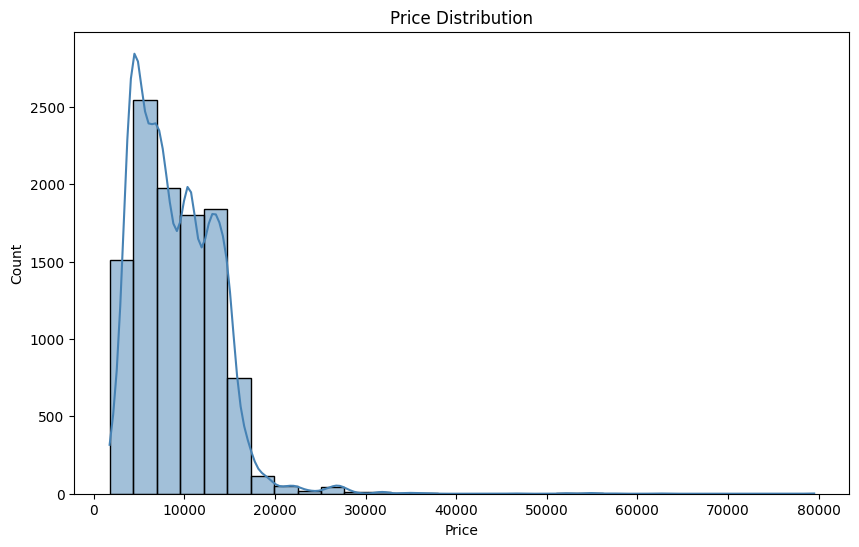

In [83]:
plt.figure(figsize=(10, 6))
sns.histplot(final_df['Price'], kde=True, bins=30, color='steelblue') #type:ignore
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

## Insight from Univariate Analysis
The ticket price distribution is right-skewed, which means most fares are in the lower-to-mid range with a few expensive outliers. This suggests price is not normally distributed and may benefit from transformation or robust modeling later.


## Step 2: Bivariate Analysis
Now we will compare each important numeric feature against the target price.

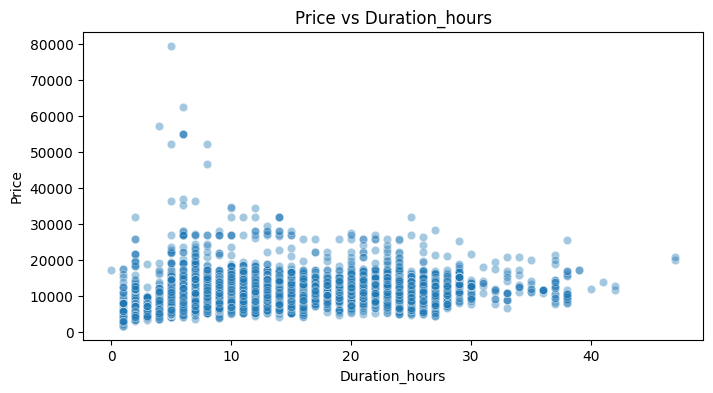

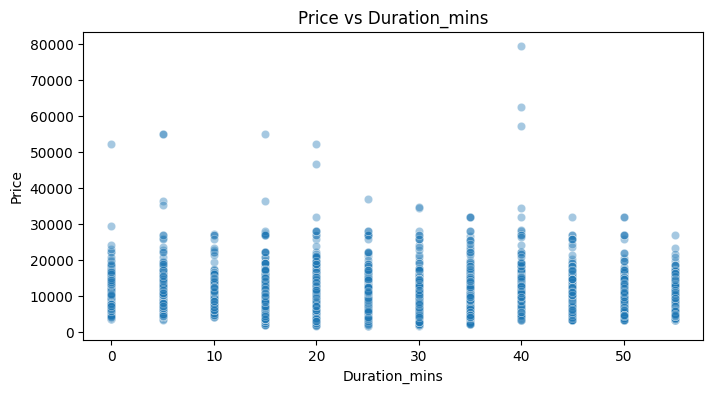

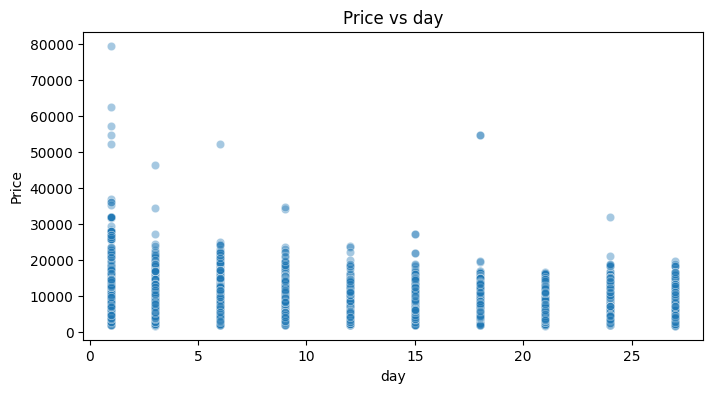

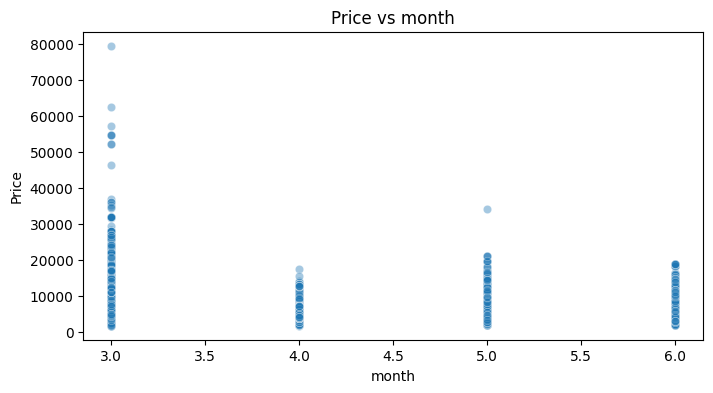

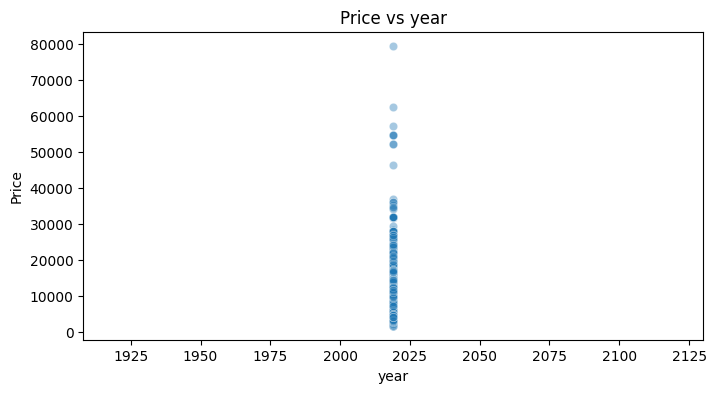

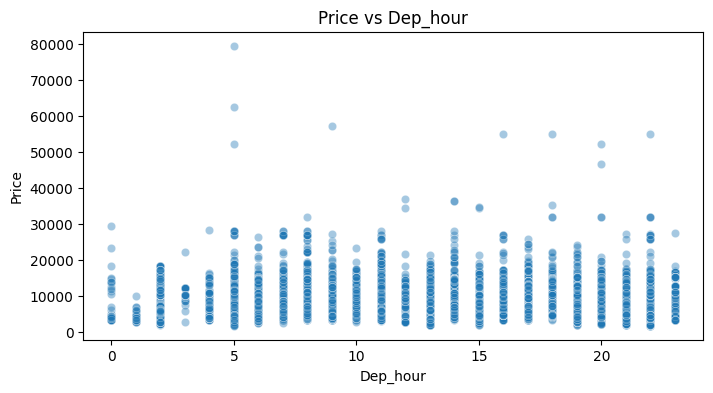

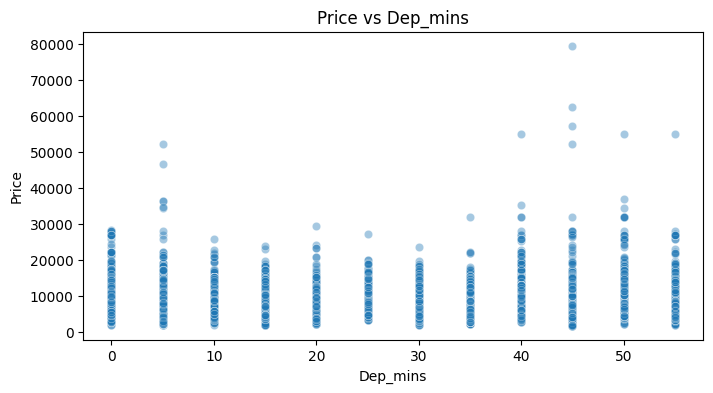

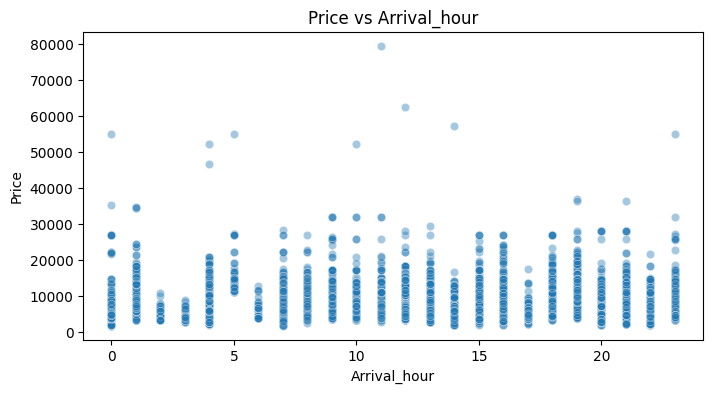

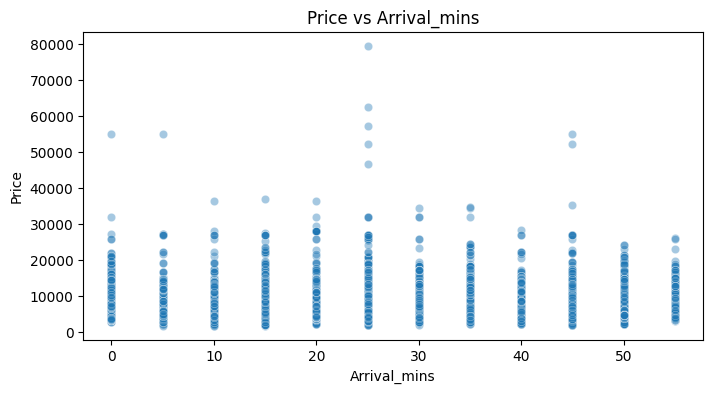

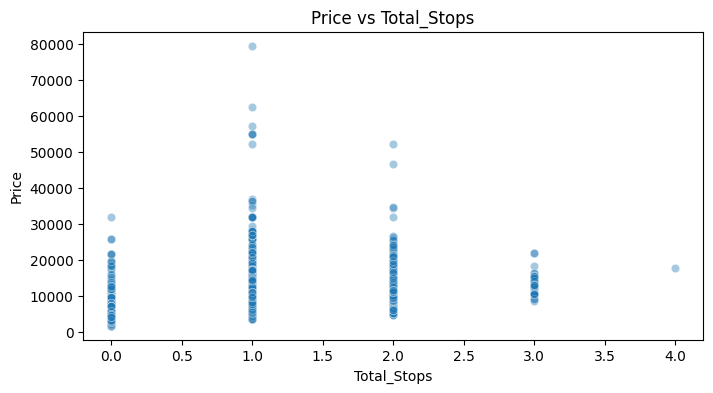

In [84]:
for column in cols:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=final_df, x=column, y='Price', alpha=0.4)
    plt.title(f'Price vs {column}')
    plt.show()

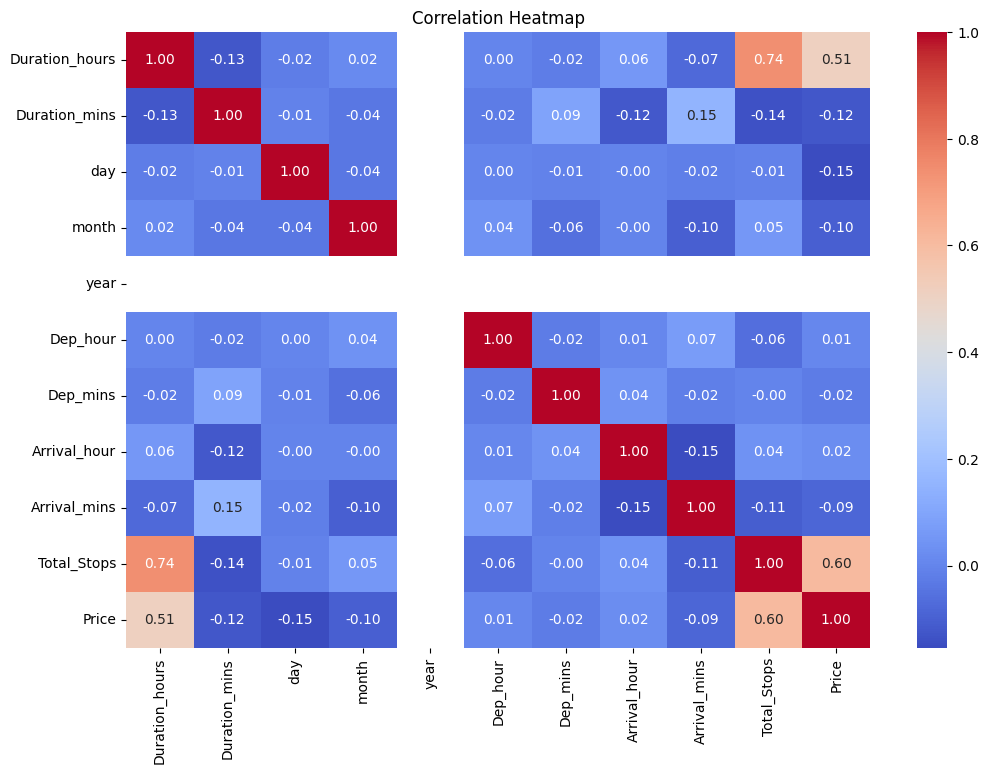

In [85]:
plt.figure(figsize=(12, 8))
sns.heatmap(final_df[cols + ['Price']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Insight from Bivariate Analysis
The scatter plots and correlation view suggest that some time-based features have a relationship with price, but the connection is not perfectly linear. Several categorical encodings also appear to matter, so price is likely influenced by a mix of route, timing, and fare class effects.


## Step 3: Multivariate Analysis
We will observe how the main numeric features behave together with the target variable.

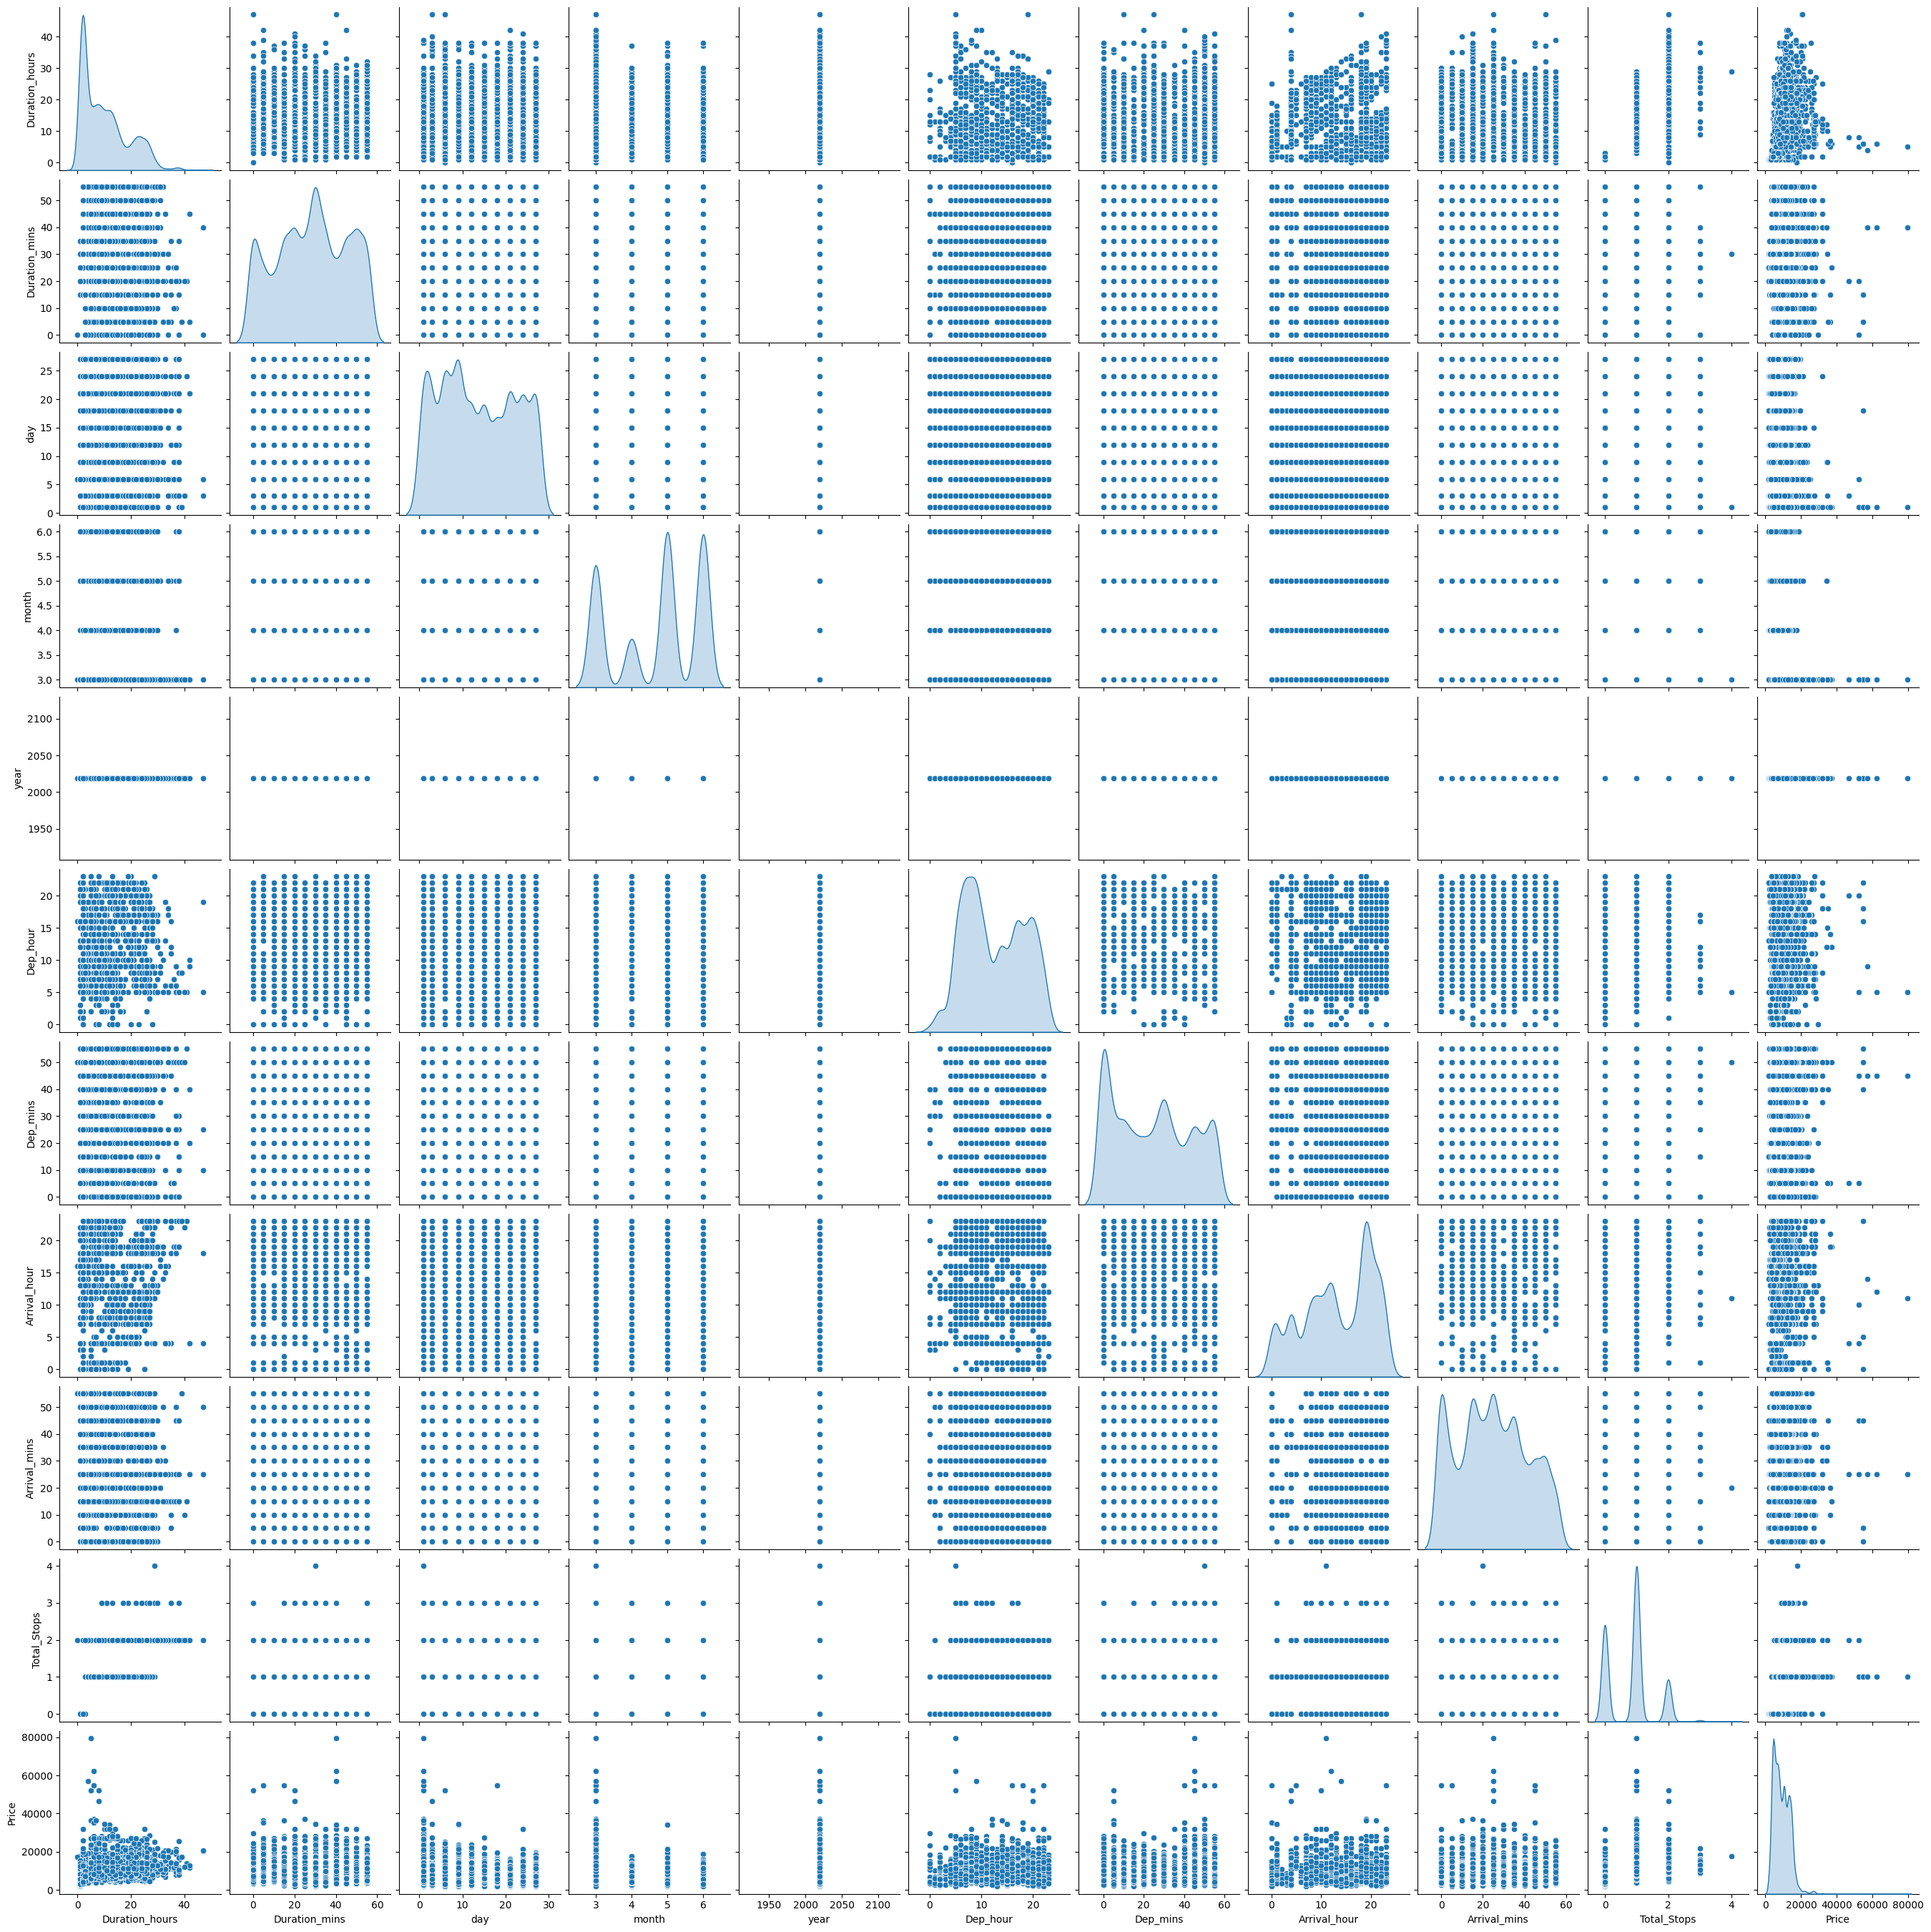

In [86]:
sns.pairplot(final_df[cols + ['Price']], diag_kind='kde')

## Insight from Multivariate Analysis
The pairwise view shows that price is shaped by multiple features together rather than a single variable alone. This means the final model should capture interactions between journey timing, duration, and stops instead of relying only on one feature.


## Step 4: Separate X and y
Here we split the data into features and target.

In [87]:
X = final_df.drop('Price', axis=1)
y = final_df['Price']
X.shape, y.shape

((10683, 43), (10683,))

## Step 5: Train-Test Split
We will keep a portion of the data for testing the model later.

In [88]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8546, 43), (2137, 43), (8546,), (2137,))

## Step 6: Scaling
Finally, we scale the numeric features to make them ready for model training.

In [89]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled.shape, X_test_scaled.shape

((8546, 43), (2137, 43))